In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


**Import Libraries**

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score

**Load Dataset**

In [3]:
import os

# Load dataset
df = pd.read_csv(os.path.join(path, "data.csv"))

# Display first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**Data Preprocessing**

In [4]:
# Drop unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis column (M = 1, B = 0)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

**Check Missing Values**

In [5]:
# Check for missing values
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


**Split Features and Target**

In [6]:
# Features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

**Train-Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Gaussian Naive Bayes Model**

In [8]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

**Predictions**

In [9]:
y_pred = model.predict(X_test)

**Evaluation Metrics**

In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9302325581395349


**Save The results**

In [12]:
# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Save to CSV
results_df.to_csv("predictions.csv", index=False)

print("Predictions saved to predictions.csv")

Predictions saved to predictions.csv


In [13]:
# Save metrics to a text file
with open("model_metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy}\n")
    f.write(f"Precision: {precision}\n")
    f.write(f"Recall: {recall}\n")

print("Metrics saved to model_metrics.txt")

Metrics saved to model_metrics.txt


In [14]:
import joblib

# Save model
joblib.dump(model, "gaussian_nb_model.pkl")

print("Model saved as gaussian_nb_model.pkl")

Model saved as gaussian_nb_model.pkl


In [15]:
# Load the saved model
loaded_model = joblib.load("gaussian_nb_model.pkl")

# Predict again to verify
y_pred_loaded = loaded_model.predict(X_test)

print("Model loaded successfully")

Model loaded successfully


**Evaluation Metrics Visualization**

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



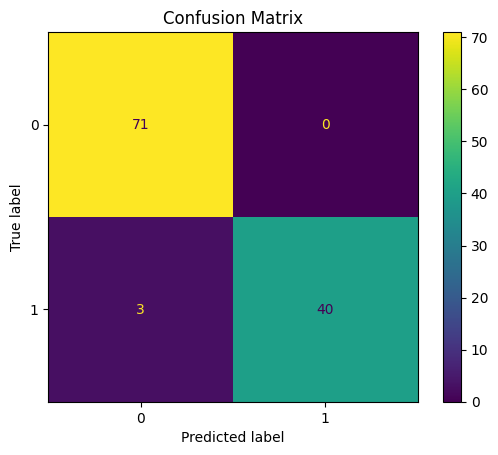

Confusion matrix saved as image


<Figure size 640x480 with 0 Axes>

In [16]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

report = classification_report(y_test, y_pred)
print(report)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()
plt.savefig("confusion_matrix.png")
print("Confusion matrix saved as image")

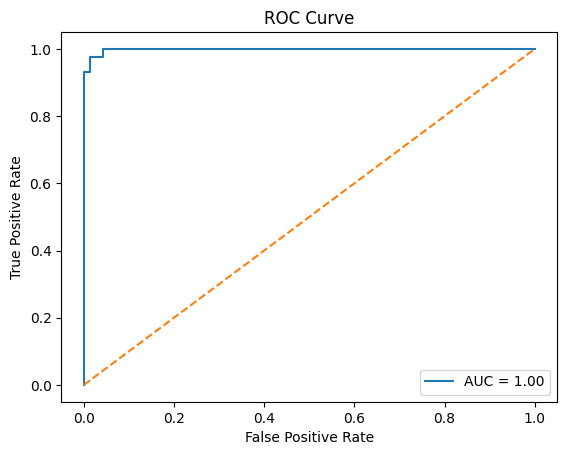

ROC curve saved as image


<Figure size 640x480 with 0 Axes>

In [19]:
from sklearn.metrics import roc_curve, auc

# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()
plt.savefig("roc_curve.png")
print("ROC curve saved as image")